In [144]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, PrecisionRecallDisplay, RocCurveDisplay, classification_report)

In [103]:
df_train = pd.read_csv("D:\\Ameng\\Data Science Project\\Titanic-Prediction\\data\\train.csv")
df_test = pd.read_csv("D:\\Ameng\\Data Science Project\\Titanic-Prediction\\data\\test.csv")

In [104]:
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## EDA

Number of Survived
Survived
0    549
1    342
Name: count, dtype: int64

Survived Percentage
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


C:\Users\akmal\AppData\Local\Temp\ipykernel_7164\1529100677.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No', 'Yes'])


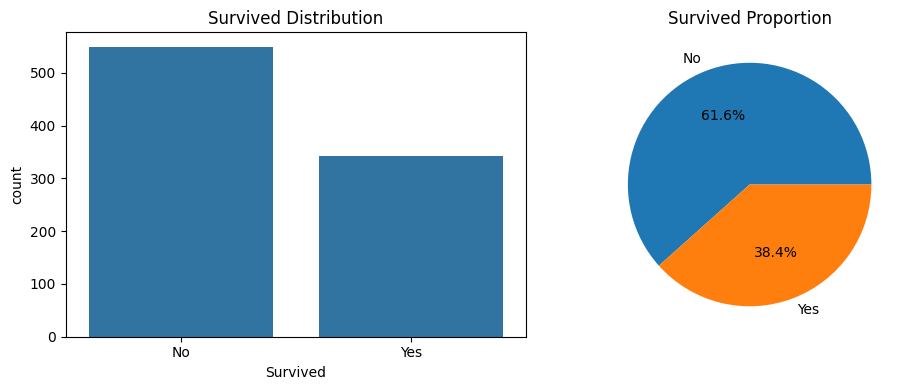

In [105]:
print("Number of Survived")
print(df_train['Survived'].value_counts())
print("\nSurvived Percentage")
print(df_train['Survived'].value_counts(normalize=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.countplot(data=df_train, x='Survived', ax=axes[0])
axes[0].set_title('Survived Distribution')
axes[0].set_xticklabels(['No', 'Yes'])

df_train['Survived'].value_counts().plot(kind='pie', 
                                     labels=['No', 'Yes'],
                                     autopct='%1.1f%%',
                                     ax=axes[1])
axes[1].set_ylabel('')
axes[1].set_title('Survived Proportion')

plt.tight_layout()
plt.show()


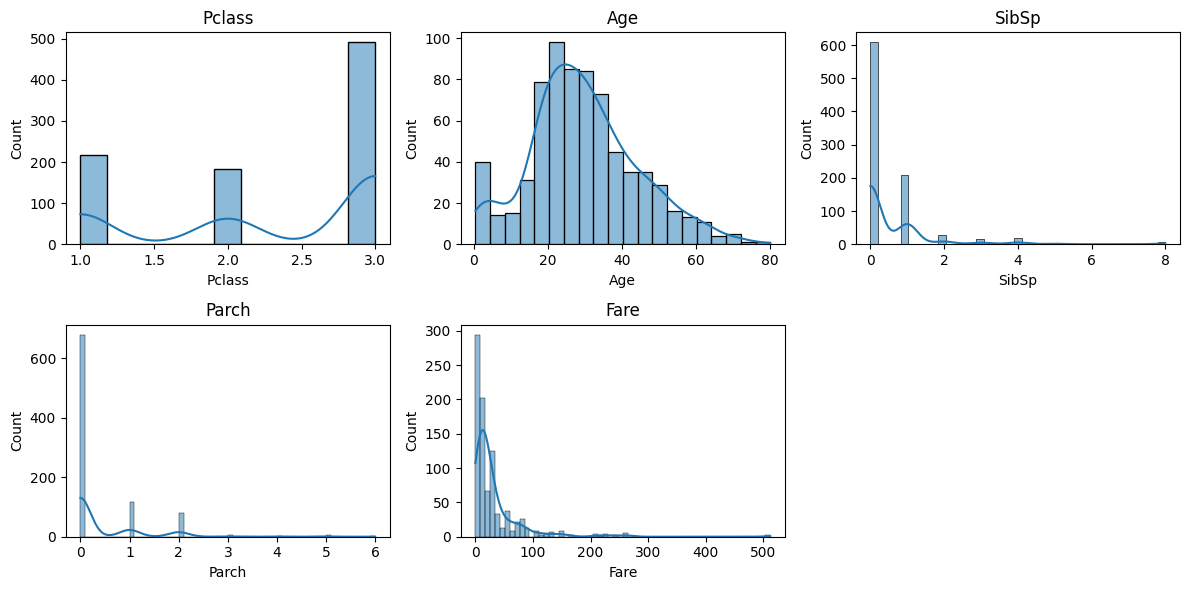

In [106]:
num_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']  # SibSp (bukan Sibsp)

plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_train[col].dropna(), kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

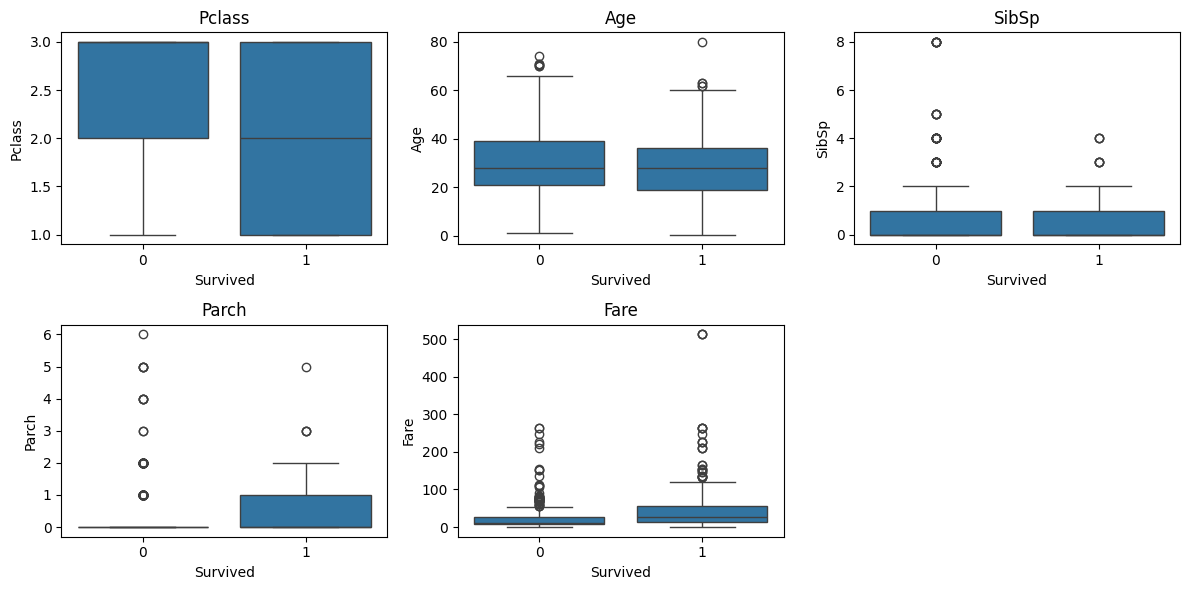

In [107]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df_train, x='Survived', y=col)
    plt.title(col)

plt.tight_layout()
plt.show()

## Preprocessing

In [108]:
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [109]:
duplicates = df_train.duplicated().sum()
duplicates

np.int64(0)

In [110]:
duplicates_test = df_test.duplicated().sum()
duplicates_test

np.int64(0)

In [111]:
df_train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [112]:
df_test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [113]:
df_train['Age'] = df_train['Age'].fillna(
    df_train.groupby(['Sex', 'Pclass'])['Age'].transform('median')
)

df_test['Age'] = df_test['Age'].fillna(
    df_test.groupby(['Sex', 'Pclass'])['Age'].transform('median')
)

In [114]:
df_train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [115]:
df_test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [116]:
df_train = df_train.drop(columns=['Cabin'])
df_test = df_test.drop(columns=['Cabin'])

Column 'Cabin' has too much missing values, so drop the 'Cabin' column is good choice because 'Cabin' column doesn't have high impact

In [117]:
df_train.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [118]:
df_test.isna().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
dtype: int64

In [119]:
df_train = df_train.dropna(subset=['Embarked'])

In [120]:
df_test['Fare'] = df_test['Fare'].fillna(df_test['Fare'].median())

In [121]:
df_train.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [122]:
df_test.isna().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Feature Engineering

In [123]:
for df in [df_train, df_test]:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
                                       'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

In [124]:
df_train = pd.get_dummies(df_train, columns=['Sex'], prefix='Sex')
df_test = pd.get_dummies(df_test, columns=['Sex'], prefix='Sex')

In [125]:
df_train = pd.get_dummies(df_train, columns=['Embarked'], prefix='Embarked')
df_test = pd.get_dummies(df_test, columns=['Embarked'], prefix='Embarked')

In [126]:
df_train = pd.get_dummies(df_train, columns=['Title'], prefix='Title')
df_test = pd.get_dummies(df_test, columns=['Title'], prefix='Title')

In [127]:
df_train.drop(columns=['Name', 'Ticket'], inplace=True, errors='ignore')
df_test.drop(columns=['Name', 'Ticket'], inplace=True, errors='ignore')

In [132]:
for df in [df_train, df_test]:
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

In [133]:
df_train

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,22.0,1,0,7.2500,2,0,0,1,0,0,1,0,0,1,0,0
1,2,1,1,38.0,1,0,71.2833,2,0,1,0,1,0,0,0,0,0,1,0
2,3,1,3,26.0,0,0,7.9250,1,1,1,0,0,0,1,0,1,0,0,0
3,4,1,1,35.0,1,0,53.1000,2,0,1,0,0,0,1,0,0,0,1,0
4,5,0,3,35.0,0,0,8.0500,1,1,0,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000,1,1,0,1,0,0,1,0,0,0,0,1
887,888,1,1,19.0,0,0,30.0000,1,1,1,0,0,0,1,0,1,0,0,0
888,889,0,3,21.5,1,2,23.4500,4,0,1,0,0,0,1,0,1,0,0,0
889,890,1,1,26.0,0,0,30.0000,1,1,0,1,1,0,0,0,0,1,0,0


In [134]:
df_test

,PassengerId,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,892,3,34.5,0,0,7.8292,1,1,0,1,0,1,0,0,0,1,0,0
1,893,3,47.0,1,0,7.0000,2,0,1,0,0,0,1,0,0,0,1,0
2,894,2,62.0,0,0,9.6875,1,1,0,1,0,1,0,0,0,1,0,0
3,895,3,27.0,0,0,8.6625,1,1,0,1,0,0,1,0,0,1,0,0
4,896,3,22.0,1,1,12.2875,3,0,1,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,24.0,0,0,8.0500,1,1,0,1,0,0,1,0,0,1,0,0
414,1306,1,39.0,0,0,108.9000,1,1,1,0,1,0,0,0,0,0,0,1
415,1307,3,38.5,0,0,7.2500,1,1,0,1,0,0,1,0,0,1,0,0
416,1308,3,24.0,0,0,8.0500,1,1,0,1,0,0,1,0,0,1,0,0


## Modelling

In [ ]:
passenger_id = df_test['PassengerId'].copy()

X = df_train.drop(columns=['Survived', 'PassengerId'], errors='ignore')
y = df_train['Survived']

X_test = df_test.drop(columns=['PassengerId'], errors='ignore')

In [142]:
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, 
    test_size=0.2,     
    random_state=42,    
    stratify=y          
)

In [145]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(n_estimators=500, random_state=42))
    ]),
    "Decision Tree": Pipeline([
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingClassifier(random_state=42))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ])
}